# DomusFM data: exploratory analysis and cleaning

Every dataset the DomusFM reproduction trains or tests on, before and after cleaning.
DomusFM only; HomeFM is not covered here.

**Run:** `.venv/Scripts/python notebooks/domusfm_eda.py` (script) or open `notebooks/domusfm_eda.ipynb`.
Figures are written to `notebooks/figures/`, tables to `notebooks/tables/`.

| Group | Datasets | Role in the run |
|---|---|---|
| CASAS pretraining homes | 75 homes (hh, tm, mn, rw, ihs, mva, mv families), 2025 Zenodo release | pretraining only |
| CASAS Milan, Aruba | 2 homes, no labels | pretraining only |
| CASAS test homes | hh101, hh103, hh105, hh110, hh119, hh122 | fine-tuning and testing |
| Paper test datasets | UCI Home B, Kasteren A, Kasteren C, MuRAL | fine-tuning and testing |

The paper (arXiv 2602.01910, §5) used Milan, Aruba, Kasteren A and C, UCI B, Orange4Home and MuRAL.
Orange4Home is available only by email request and is not included.

In [1]:
import json
import re
import sys
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd() if (Path.cwd() / "src").exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))

from homefm.baselines.domusfm.clean import clean_dataset  # noqa: E402
from homefm.baselines.domusfm.run import load_datasets  # noqa: E402
from homefm.train.pretrain import load_config  # noqa: E402

FIG, TAB = ROOT / "notebooks" / "figures", ROOT / "notebooks" / "tables"
FIG.mkdir(parents=True, exist_ok=True)
TAB.mkdir(parents=True, exist_ok=True)

# Reference categorical palette (fixed order, light mode) and chart styling: thin marks, recessive axes.
SLOTS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight", "font.size": 9,
    "axes.edgecolor": GRID, "axes.labelcolor": INK2, "axes.titlesize": 11, "axes.titleweight": "bold",
    "axes.titlecolor": INK, "axes.spines.top": False, "axes.spines.right": False, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.6, "xtick.color": INK2, "ytick.color": INK2,
    "legend.frameon": False, "axes.axisbelow": True,
})
GROUPS = ["CASAS pretraining", "CASAS Milan/Aruba", "CASAS test", "Paper test"]
GROUP_COLOR = dict(zip(GROUPS, SLOTS))


def save(fig, name):
    fig.savefig(FIG / f"{name}.png")
    plt.show()

## 1. Load every dataset

The loaders are the ones the training run uses (`homefm.baselines.domusfm.run.load_datasets`), so what is
analysed here is exactly what the model sees: events after DomusFM's ON/OFF conversion, with one activity label per
event (label 0 = "Other"). Cleaning is off at this point.

In [2]:
cfg = load_config(str(ROOT / "configs/domusfm_corpus_clean.yaml"), [],
                  base=str(ROOT / "configs/domusfm.yaml"))
cfg["datasets"]["clean"] = False
datasets, pretrain_only = load_datasets(cfg)
held_out = set(cfg["held_out"])
PAPER = {"uci_b", "kasteren_a", "kasteren_c", "mural"}


def group(name):
    if name in PAPER:
        return "Paper test"
    if name in held_out:
        return "CASAS test"
    return "CASAS Milan/Aruba" if name in ("milan", "aruba") else "CASAS pretraining"


def family(name):
    return name if name in PAPER | {"milan", "aruba"} else re.sub(r"\d+$", "", name)


print(len(datasets), "datasets,", sum(d.n_events for d in datasets), "events")

87 datasets, 28120516 events


## 2. Overview

In [3]:
rows = []
for d in datasets:
    days = (d.ts[-1] - d.ts[0]) / 86400
    start = pd.Timestamp(d.ts[0], unit="s")
    rows.append(dict(dataset=d.name, group=group(d.name), family=family(d.name), events=d.n_events,
                     days=round(days, 1), start=start.date(), end=pd.Timestamp(d.ts[-1], unit="s").date(),
                     year=start.year, sensors=len(d.sensor_ids), classes=len(d.activities),
                     events_per_day=round(d.n_events / max(days, 1e-9)),
                     labelled_share=round(float((d.label > 0).mean()), 3)))
overview = pd.DataFrame(rows)
overview.to_csv(TAB / "overview.csv", index=False)
summary = overview.groupby("group").agg(datasets=("dataset", "count"), events=("events", "sum"),
                                        sensors_min=("sensors", "min"), sensors_max=("sensors", "max"),
                                        first_year=("year", "min"), last_year=("year", "max"),
                                        median_days=("days", "median")).reindex(GROUPS)
summary

,datasets,events,sensors_min,sensors_max,first_year,last_year,median_days
group,,,,,,,
CASAS pretraining,75,25231288,5,46,2011,2023,32.00
CASAS Milan/Aruba,2,2024213,11,11,2009,2010,151.25
CASAS test,6,803768,7,11,2011,2013,44.25
Paper test,4,61247,12,23,2008,2024,24.50


In [4]:
overview[overview.group.isin(["CASAS test", "Paper test"])].sort_values("group")

,dataset,group,family,events,days,start,end,year,sensors,classes,events_per_day,labelled_share
4,hh101,CASAS test,hh,222858,59.6,2012-07-20,2012-09-17,2012,7,35,3742,0.721
5,hh103,CASAS test,hh,112474,57.5,2011-06-15,2011-08-11,2011,8,33,1956,0.707
6,hh105,CASAS test,hh,147074,60.7,2011-06-15,2011-08-14,2011,10,34,2424,0.608
7,hh110,CASAS test,hh,98686,30.4,2011-06-15,2011-07-15,2011,11,32,3246,0.708
8,hh119,CASAS test,hh,92740,31.0,2012-01-28,2012-02-27,2012,8,33,2994,0.701
9,hh122,CASAS test,hh,129936,29.9,2013-04-01,2013-04-30,2013,8,34,4344,0.667
0,uci_b,Paper test,uci_b,4668,21.2,2012-11-11,2012-12-03,2012,12,11,221,0.639
1,kasteren_a,Paper test,kasteren_a,2636,27.8,2008-02-25,2008-03-23,2008,14,8,95,0.795
2,kasteren_c,Paper test,kasteren_c,45400,18.4,2008-11-19,2008-12-08,2008,21,18,2468,0.948
3,mural,Paper test,mural,8543,140.5,2024-01-03,2024-05-22,2024,23,27,61,0.983


## 3. How old is the data?

Recording period of every dataset. The CASAS homes span 2009–2023; the paper test datasets span 2008
(Kasteren) to 2024–25 (MuRAL, whose sessions have only times of day and are placed on a dummy 2024 calendar by
the converter, so its position here is not a real date).

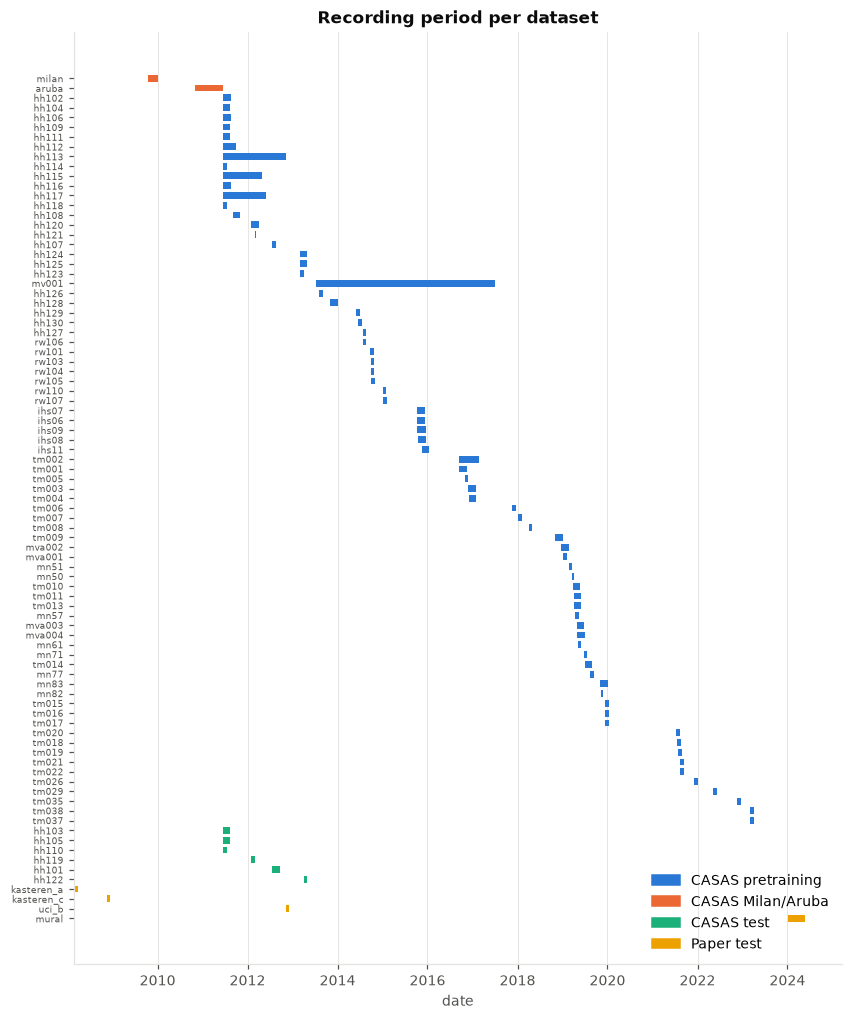

In [5]:
tl = overview.sort_values(["group", "start"])
fig, ax = plt.subplots(figsize=(9, 11))
for i, r in enumerate(tl.itertuples()):
    s, e = pd.Timestamp(r.start), pd.Timestamp(r.end)
    ax.barh(i, (e - s).days + 1, left=s, height=0.7, color=GROUP_COLOR[r.group])
ax.set_yticks(range(len(tl)), tl.dataset, fontsize=6)
ax.invert_yaxis()
ax.set_title("Recording period per dataset")
ax.set_xlabel("date")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUPS], labels=GROUPS,
          loc="lower right")
ax.grid(axis="y", visible=False)
save(fig, "01_recording_timeline")

## 4. Size: events per dataset

Sizes differ by more than three orders of magnitude (log scale). Pretraining samples each dataset equally often
(the paper's dataset-level oversampling, §6.1.2), so a big home does not dominate.

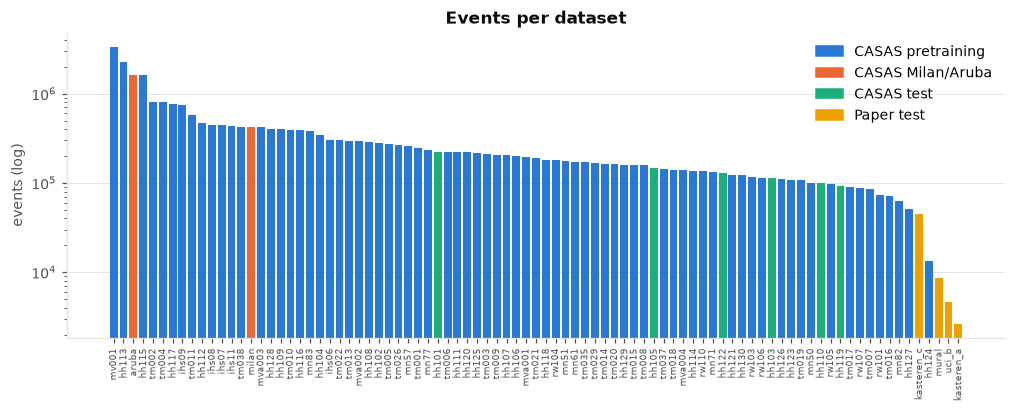

In [6]:
o = overview.sort_values("events", ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(range(len(o)), o.events, color=[GROUP_COLOR[g] for g in o.group], width=0.8)
ax.set_yscale("log")
ax.set_xticks(range(len(o)), o.dataset, rotation=90, fontsize=6)
ax.set_ylabel("events (log)")
ax.set_title("Events per dataset")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUPS], labels=GROUPS)
ax.grid(axis="x", visible=False)
save(fig, "02_events_per_dataset")

## 5. What kinds of sensors are there?

Share of events by sensor type. CASAS homes are almost entirely motion sensors, with a few doors and
thermometers. "Numeric codes" are undocumented numbers on motion-sensor names in the 2025 CASAS release, which
the loader turns into invented ON/OFF events. The paper test datasets add item-level contacts (cupboards, fridge,
toilet flush), pressure mats and power meters.

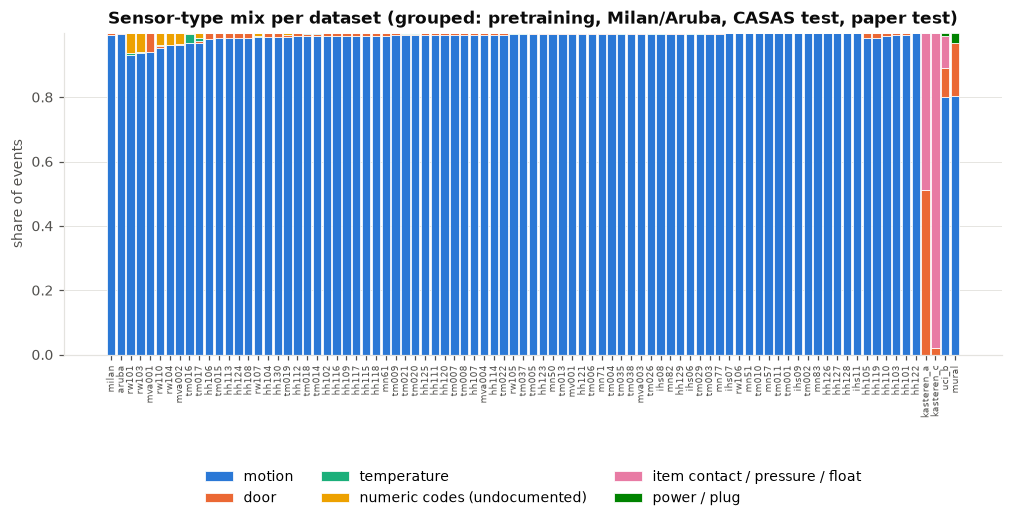

,motion,door,temperature,numeric codes (undocumented),item contact / pressure / float,power / plug
group,,,,,,
CASAS pretraining,0.990,0.005,0.001,0.004,0.000,0.00
CASAS Milan/Aruba,0.995,0.005,0.000,0.000,0.000,0.00
CASAS test,0.991,0.009,0.000,0.000,0.000,0.00
Paper test,0.401,0.196,0.000,0.000,0.392,0.01


In [7]:
TYPE_BUCKET = {"motion": "motion", "door contact": "door", "temperature": "temperature",
               "scalar": "numeric codes (undocumented)", "power meter": "power / plug", "power plug": "power / plug"}
BUCKETS = ["motion", "door", "temperature", "numeric codes (undocumented)", "item contact / pressure / float",
           "power / plug"]
comp = []
for d in datasets:
    types = np.array([TYPE_BUCKET.get(t[1], "item contact / pressure / float") for t in d.sensor_text])
    c = Counter(types[d.sensor])
    comp.append({"dataset": d.name, "group": group(d.name), **{b: c.get(b, 0) / d.n_events for b in BUCKETS}})
comp = pd.DataFrame(comp).set_index("dataset")
comp.to_csv(TAB / "sensor_type_share.csv")
order = comp.sort_values(["group", "motion"]).index

fig, ax = plt.subplots(figsize=(11, 3.8))
bottom = np.zeros(len(order))
for b, col in zip(BUCKETS, SLOTS):
    v = comp.loc[order, b].values
    ax.bar(range(len(order)), v, bottom=bottom, color=col, width=0.85, label=b, edgecolor="white", linewidth=0.5)
    bottom += v
ax.set_xticks(range(len(order)), order, rotation=90, fontsize=6)
ax.set_ylabel("share of events")
ax.set_title("Sensor-type mix per dataset (grouped: pretraining, Milan/Aruba, CASAS test, paper test)")
ax.legend(ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.32))
ax.grid(axis="x", visible=False)
save(fig, "03_sensor_type_mix")
comp.groupby("group")[BUCKETS].mean().reindex(GROUPS).round(3)

### Sensor names per home, by family

The 2025 CASAS release merges the physical sensors of a room into one name. The hh homes keep 5–8 names (the
hh101 floorplan shows about 40 physical sensors); newer families keep more detail.

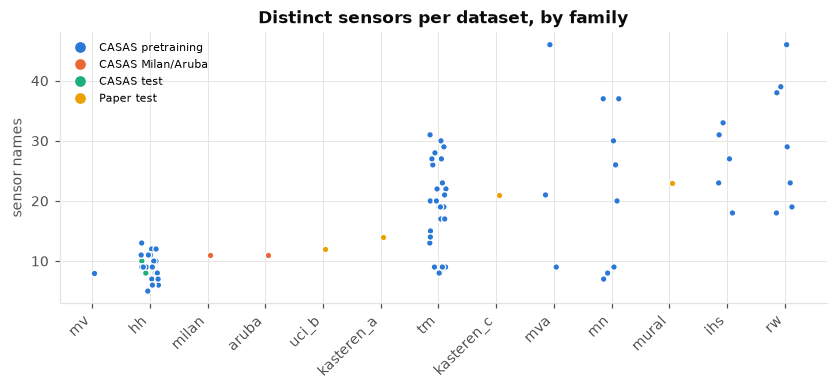

In [8]:
fams = overview.groupby("family").sensors.median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 3.2))
for i, f in enumerate(fams):
    v = overview[overview.family == f]
    ax.scatter(np.full(len(v), i) + np.random.default_rng(0).uniform(-0.15, 0.15, len(v)), v.sensors, s=18,
               color=[GROUP_COLOR[g] for g in v.group], edgecolor="white", linewidth=0.8, zorder=3)
ax.set_xticks(range(len(fams)), fams, rotation=45, ha="right")
ax.set_ylabel("sensor names")
ax.set_title("Distinct sensors per dataset, by family")
ax.legend(handles=[plt.Line2D([], [], marker="o", ls="", color=GROUP_COLOR[g]) for g in GROUPS], labels=GROUPS,
          fontsize=7)
save(fig, "04_sensors_per_family")

## 6. Daily rhythm

Share of events per hour of day, averaged over the datasets in each group (each dataset weighted equally).
The shape is similar across groups (quiet at night, peaks in the morning and evening), which is why routines
learned on old CASAS homes can carry over. MuRAL sessions were recorded only at set times, so its profile is
not a full day.

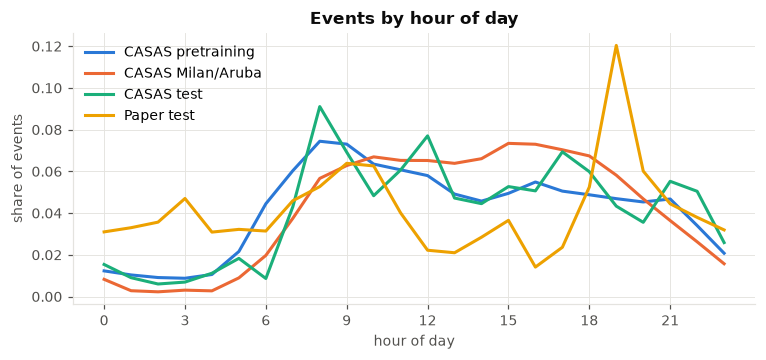

In [9]:
def hour_profile(d):
    h = ((d.ts % 86400) // 3600).astype(int)
    return np.bincount(h, minlength=24) / d.n_events


prof = {g: np.mean([hour_profile(d) for d in datasets if group(d.name) == g], axis=0) for g in GROUPS}
fig, ax = plt.subplots(figsize=(8, 3.2))
for g in GROUPS:
    ax.plot(range(24), prof[g], color=GROUP_COLOR[g], lw=2, label=g)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of day")
ax.set_ylabel("share of events")
ax.set_title("Events by hour of day")
ax.legend()
save(fig, "05_hour_profile")

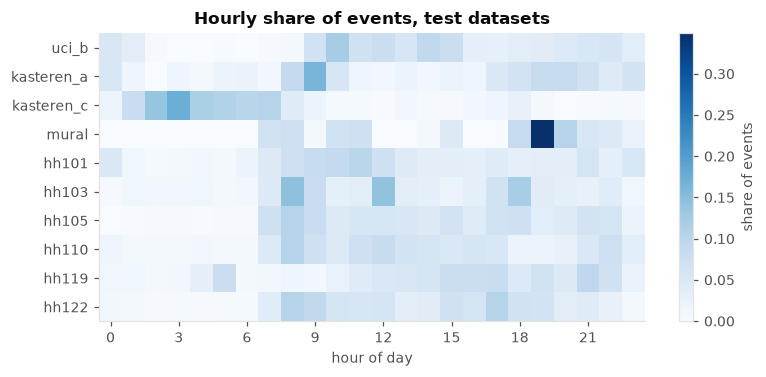

In [10]:
tests = [d for d in datasets if d.name in held_out]
mat = np.array([hour_profile(d) for d in tests])
fig, ax = plt.subplots(figsize=(8, 3.4))
im = ax.imshow(mat, aspect="auto", cmap="Blues")
ax.set_yticks(range(len(tests)), [d.name for d in tests])
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("hour of day")
ax.set_title("Hourly share of events, test datasets")
ax.grid(False)
fig.colorbar(im, ax=ax, label="share of events")
save(fig, "06_hour_heatmap_tests")

## 7. How much time does one 30-event window cover?

DomusFM reads windows of 30 events (§6.2.2). The paper notes (§7.2) that the time a window covers varies across
datasets. Here: the time from the first to the last event of every window, per test dataset (log scale).

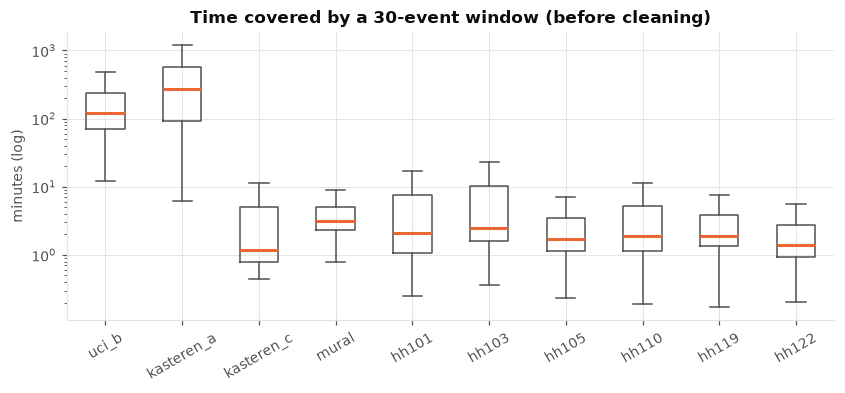

,uci_b,kasteren_a,kasteren_c,mural,hh101,hh103,hh105,hh110,hh119,hh122
p10 min,43.3,53.3,0.7,1.9,0.7,1.3,0.9,0.8,1.0,0.7
median min,120.7,272.2,1.2,3.2,2.1,2.5,1.7,1.9,1.9,1.4
p90 min,522.1,731.2,29.8,12.3,20.7,79.3,12.7,22.7,30.1,13.5


In [11]:
def window_spans(d, w=30):
    return (d.ts[w - 1:] - d.ts[: len(d.ts) - w + 1]) / 60.0


spans = {d.name: window_spans(d) for d in tests}
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.boxplot([np.clip(v, 1e-2, None) for v in spans.values()], showfliers=False, widths=0.5,
           medianprops=dict(color=SLOTS[1], lw=2), boxprops=dict(color=INK2), whiskerprops=dict(color=INK2),
           capprops=dict(color=INK2))
ax.set_xticks(range(1, len(spans) + 1), spans.keys(), rotation=30)
ax.set_yscale("log")
ax.set_ylabel("minutes (log)")
ax.set_title("Time covered by a 30-event window (before cleaning)")
save(fig, "07_window_span_before")
pd.DataFrame({k: np.percentile(v, [10, 50, 90]) for k, v in spans.items()}, index=["p10 min", "median min",
                                                                                     "p90 min"]).round(1)

## 8. Labels on the test datasets

What the ADL head is trained to predict: the activity at the last event of each window. "Other" (label 0) is kept
as a class, as in the paper (§6.1.1). Kasteren C is dominated by "go to bed" because the bed pressure mat fires
every few seconds during sleep.

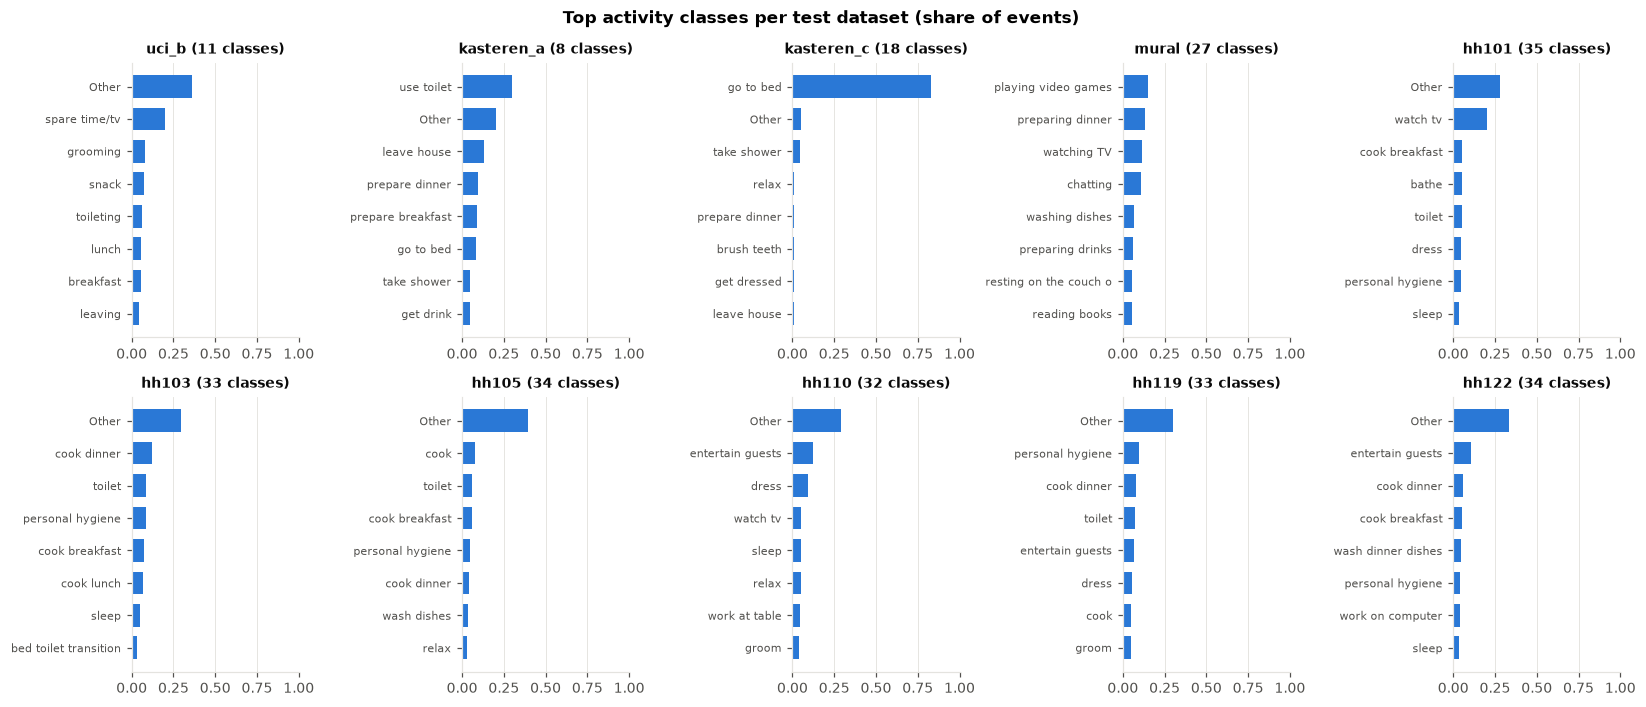

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for ax, d in zip(axes.flat, tests):
    c = pd.Series(np.array(d.activities)[d.label]).value_counts(normalize=True).head(8)[::-1]
    ax.barh(range(len(c)), c.values, color=SLOTS[0], height=0.7)
    ax.set_yticks(range(len(c)), [s[:22] for s in c.index], fontsize=7)
    ax.set_title(f"{d.name} ({len(d.activities)} classes)", fontsize=9)
    ax.grid(axis="y", visible=False)
    ax.set_xlim(0, 1)
fig.suptitle("Top activity classes per test dataset (share of events)", fontweight="bold")
fig.tight_layout()
save(fig, "08_label_distribution_tests")

## 9. Data quality

### 9.1 Raw-file checks (CASAS)

Things the loaders silently skip or that cannot be seen after loading: malformed readings, rows out of time
order, activity labels with a begin and no end (or the reverse), and recording outages.

In [13]:
LAB = re.compile(r'^(.*?)(?:="(begin|end)")?$')
NUM = re.compile(r"^-?\d+(\.\d+)?$")


def raw_scan(path):
    r = Counter()
    prev, open_ = None, Counter()
    with open(path, errors="ignore") as f:
        for line in f:
            p = line.rstrip("\n").split(",")
            if len(p) < 4 or not p[2]:
                continue
            r["rows"] += 1
            m = p[3].strip()
            if m.upper() not in ("ON", "OFF", "OPEN", "CLOSE"):
                if NUM.match(m):
                    r["numeric" if "Temperature" in p[2] else "numeric_on_non_temperature"] += 1
                else:
                    r["malformed"] += 1
            t = p[0] + "T" + p[1]
            r["out_of_order"] += bool(prev and t < prev)
            prev = t
            if len(p) > 4 and p[4].strip():
                c, edge = LAB.match(p[4].strip()).groups()
                if edge == "begin":
                    r["dangling_begin"] += open_[c]
                    open_[c] = 1
                elif edge == "end":
                    r["unmatched_end"] += 1 - open_[c]
                    open_[c] = 0
    r["dangling_begin"] += sum(open_.values())
    return r


cache = ROOT / "data/cache/eda_raw_scan.json"
casas_files = {p.stem: p for p in sorted((ROOT / "data/raw/casas/labeled").glob("*.csv"))}
casas_files.update(milan=ROOT / "data/raw/casas/data/milan.csv", aruba=ROOT / "data/raw/casas/data/aruba.csv")
scan = json.loads(cache.read_text()) if cache.exists() else {}
for name, p in casas_files.items():
    if name not in scan:
        scan[name] = raw_scan(p)
cache.write_text(json.dumps(scan))
raw = pd.DataFrame(scan).T.fillna(0).astype(int)
raw = raw[[c for c in ["rows", "numeric", "numeric_on_non_temperature", "malformed", "out_of_order",
                       "dangling_begin", "unmatched_end"] if c in raw]]
raw.to_csv(TAB / "casas_raw_checks.csv")
raw.sum().to_frame("total over all CASAS files")

,total over all CASAS files
rows,28372840
numeric,60326
numeric_on_non_temperature,308694
malformed,324
out_of_order,22
dangling_begin,438
unmatched_end,499


In [14]:
gaps = pd.Series({d.name: int((np.diff(d.ts) > 86400).sum()) for d in datasets})
issues = raw.loc[raw.index.isin(overview.dataset)].assign(outages_over_1_day=gaps)
issues[(issues.drop(columns="rows") > 0).any(axis=1)].sort_values("numeric_on_non_temperature", ascending=False) \
    .head(20)

,rows,numeric,numeric_on_non_temperature,malformed,out_of_order,dangling_begin,unmatched_end,outages_over_1_day
mva002,365871,2050,81278,1,0,0,0,0
rw104,228225,321,56557,0,1,0,0,1
rw103,154289,903,43972,0,0,0,0,0
rw110,172488,2437,41214,309,0,1,1,0
rw101,108862,1122,40153,0,0,0,0,1
tm017,101337,4309,8735,0,1,0,0,0
hh117,778094,0,7905,0,0,0,0,13
hh115,1605566,0,5456,0,0,1,0,6
ihs09,757109,0,3919,1,2,2,2,0
ihs07,451519,6154,2902,0,1,0,0,0


### 9.2 Repeated states (paper, Appendix A)

The paper: a binary sensor's events must alternate ON/OFF, and a repeated state is a duplicate event that is
"safely removed during the data cleaning process prior to segmentation". Our reproduction did not do this until
now. Share of events that repeat their sensor's previous state:

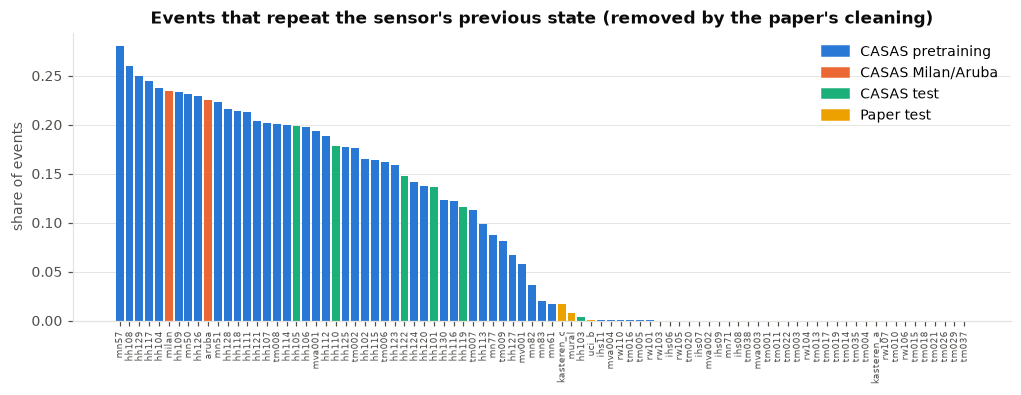

,mean,min,max
CASAS pretraining,0.084,0.000,0.280
CASAS Milan/Aruba,0.230,0.225,0.234
CASAS test,0.130,0.003,0.199
Paper test,0.006,0.000,0.017


In [15]:
def repeat_share(d):
    order = np.lexsort((d.ts, d.sensor))
    s, st = d.sensor[order], d.status[order]
    return float(((s[1:] == s[:-1]) & (st[1:] == st[:-1])).sum() / max(d.n_events, 1))


rep = pd.Series({d.name: repeat_share(d) for d in datasets})
o = rep.sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.4))
ax.bar(range(len(o)), o.values, color=[GROUP_COLOR[group(n)] for n in o.index], width=0.8)
ax.set_xticks(range(len(o)), o.index, rotation=90, fontsize=6)
ax.set_ylabel("share of events")
ax.set_title("Events that repeat the sensor's previous state (removed by the paper's cleaning)")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=GROUP_COLOR[g]) for g in GROUPS], labels=GROUPS)
ax.grid(axis="x", visible=False)
save(fig, "09_repeated_states")
rep.groupby(rep.index.map(group)).describe()[["mean", "min", "max"]].reindex(GROUPS).round(3)

## 10. Cleaning

`homefm.baselines.domusfm.clean.clean_dataset`, switched on with `datasets.clean: true`:

1. drop the undocumented numeric codes (sensor type "scalar"); temperature is kept;
2. merge sensor names that differ only in letter case;
3. drop repeated states (paper Appendix A), which also removes exact duplicate rows.

Malformed readings are already skipped by the loaders. Out-of-order rows are re-sorted by the loaders.
Unmatched activity labels and outages are left as they are: they are rare and there is no safe automatic fix.

In [16]:
cleaned, reports = [], {}
for d in datasets:
    c, r = clean_dataset(d)
    cleaned.append(c)
    reports[d.name] = r
rep_df = pd.DataFrame(reports).T
rep_df["removed_share"] = 1 - rep_df.events_out / rep_df.events_in
rep_df["group"] = rep_df.index.map(group)
rep_df.to_csv(TAB / "cleaning_report.csv")
by_group = rep_df.groupby("group")[["events_in", "dropped_type_events", "dropped_repeat_events",
                                    "events_out"]].sum().reindex(GROUPS)
by_group["removed_share"] = (1 - by_group.events_out / by_group.events_in).round(3)
by_group

,events_in,dropped_type_events,dropped_repeat_events,events_out,removed_share
group,,,,,
CASAS pretraining,25231288,42892,2222092,22966304,0.090
CASAS Milan/Aruba,2024213,0,459835,1564378,0.227
CASAS test,803768,26,107509,696233,0.134
Paper test,61247,0,818,60429,0.013


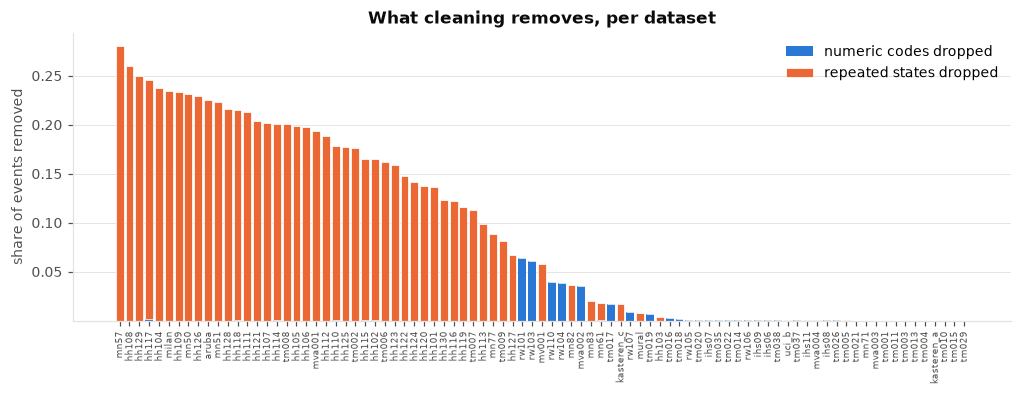

,events_in,events_out,removed_share,sensors_in,sensors_out
hh101,222858,192507,0.136190,7,7
hh103,112474,112102,0.003307,8,8
hh105,147074,117784,0.199151,10,10
hh110,98686,81078,0.178424,11,10
hh119,92740,81974,0.116088,8,8
hh122,129936,110788,0.147365,8,8
kasteren_a,2636,2636,0.000000,14,14
kasteren_c,45400,44648,0.016564,21,21
mural,8543,8479,0.007492,23,23
uci_b,4668,4666,0.000428,12,12


In [17]:
o = rep_df.sort_values("removed_share", ascending=False)
fig, ax = plt.subplots(figsize=(11, 3.4))
a = (o.dropped_type_events / o.events_in).values
b = (o.dropped_repeat_events / o.events_in).values
ax.bar(range(len(o)), a, color=SLOTS[0], width=0.8, label="numeric codes dropped")
ax.bar(range(len(o)), b, bottom=a, color=SLOTS[1], width=0.8, label="repeated states dropped",
       edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(o)), o.index, rotation=90, fontsize=6)
ax.set_ylabel("share of events removed")
ax.set_title("What cleaning removes, per dataset")
ax.legend()
ax.grid(axis="x", visible=False)
save(fig, "10_cleaning_removed")
rep_df.loc[sorted(held_out), ["events_in", "events_out", "removed_share", "sensors_in", "sensors_out"]]

### After cleaning: time covered by a window, and label mix

With repeats removed, a 30-event window covers more real time and more distinct actions.

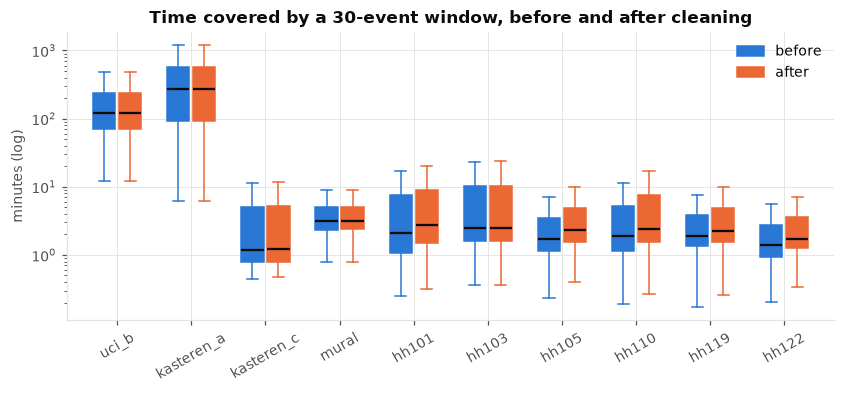

,uci_b,kasteren_a,kasteren_c,mural,hh101,hh103,hh105,hh110,hh119,hh122
median min before,120.7,272.2,1.2,3.2,2.1,2.5,1.7,1.9,1.9,1.4
median min after,120.8,272.2,1.2,3.2,2.8,2.5,2.3,2.4,2.2,1.7


In [18]:
tests_c = [c for c in cleaned if c.name in held_out]
spans_c = {d.name: window_spans(d) for d in tests_c}
fig, ax = plt.subplots(figsize=(9, 3.4))
pos = np.arange(len(spans))
for k, (sp, col, lab) in enumerate([(spans, SLOTS[0], "before"), (spans_c, SLOTS[1], "after")]):
    bp = ax.boxplot([np.clip(v, 1e-2, None) for v in sp.values()], positions=pos + (k - 0.5) * 0.35,
                    widths=0.3, showfliers=False, patch_artist=True, medianprops=dict(color=INK, lw=1.5),
                    boxprops=dict(facecolor=col, color=col), whiskerprops=dict(color=col), capprops=dict(color=col))
ax.set_xticks(pos, spans.keys(), rotation=30)
ax.set_yscale("log")
ax.set_ylabel("minutes (log)")
ax.set_title("Time covered by a 30-event window, before and after cleaning")
ax.legend(handles=[plt.Rectangle((0, 0), 1, 1, color=SLOTS[0]), plt.Rectangle((0, 0), 1, 1, color=SLOTS[1])],
          labels=["before", "after"])
save(fig, "11_window_span_after")
pd.DataFrame({k: [np.median(spans[k]), np.median(spans_c[k])] for k in spans}, index=["median min before",
                                                                                      "median min after"]).round(1)

In [19]:
lab = pd.DataFrame({d.name: {"labelled share before": float((d.label > 0).mean()),
                             "labelled share after": float((c.label > 0).mean())}
                    for d, c in zip(datasets, cleaned) if d.name in held_out}).T.round(3)
lab

,labelled share before,labelled share after
uci_b,0.639,0.638
kasteren_a,0.795,0.795
kasteren_c,0.948,0.947
mural,0.983,0.983
hh101,0.721,0.763
hh103,0.707,0.708
hh105,0.608,0.641
hh110,0.708,0.735
hh119,0.701,0.721
hh122,0.667,0.659


## 11. Findings

Printed from the numbers above, so they stay correct if the data changes.

In [20]:
pre = overview[overview.group.isin(["CASAS pretraining", "CASAS Milan/Aruba"])]
casas_types = comp[comp.group != "Paper test"][BUCKETS].mean()
print(f"Pretraining corpus: {len(pre)} homes, {pre.events.sum():,} events, recorded {pre.year.min()}–"
      f"{overview[overview.group != 'Paper test'].end.max().year}.")
print(f"CASAS event mix (mean over homes): motion {casas_types['motion']:.1%}, door {casas_types['door']:.1%}, "
      f"temperature {casas_types['temperature']:.1%}, undocumented numeric codes "
      f"{casas_types['numeric codes (undocumented)']:.1%}. No power, water, light, audio or camera sensors.")
casas_sensors = rep_df[rep_df.group != "Paper test"].sensors_out
print(f"Sensors per CASAS home after cleaning: {casas_sensors.min()}–{casas_sensors.max()} "
      f"(before: up to {rep_df[rep_df.group != 'Paper test'].sensors_in.max()}, because numeric codes on a motion "
      f"name were counted as a second sensor).")
print(f"Raw CASAS problems: {raw.numeric_on_non_temperature.sum():,} numeric codes on motion names, "
      f"{raw.malformed.sum():,} malformed readings, {raw.out_of_order.sum()} rows out of order, "
      f"{raw.dangling_begin.sum() + raw.unmatched_end.sum():,} unmatched activity labels, "
      f"{int(gaps.sum())} outages over 1 day.")
print(f"Cleaning removes {1 - by_group.events_out.sum() / by_group.events_in.sum():.1%} of all events: "
      + ", ".join(f"{g} {by_group.loc[g, 'removed_share']:.1%}" for g in GROUPS) + ".")

Pretraining corpus: 77 homes, 27,255,501 events, recorded 2009–2023.
CASAS event mix (mean over homes): motion 99.0%, door 0.6%, temperature 0.1%, undocumented numeric codes 0.3%. No power, water, light, audio or camera sensors.
Sensors per CASAS home after cleaning: 5–36 (before: up to 46, because numeric codes on a motion name were counted as a second sensor).
Raw CASAS problems: 308,694 numeric codes on motion names, 324 malformed readings, 22 rows out of order, 937 unmatched activity labels, 84 outages over 1 day.
Cleaning removes 10.1% of all events: CASAS pretraining 9.0%, CASAS Milan/Aruba 22.7%, CASAS test 13.4%, Paper test 1.3%.
